# Titanic: survival prediction with scikit-learn pipelines

[Kaggle competition](https://www.kaggle.com/competitions/titanic) - predict which passengers survived the sinking of the
RMS Titanic from their ticket, cabin and demographic data. The metric is **accuracy**.

The goal of this notebook is less about squeezing the leaderboard and more about doing the basics properly:

1. **EDA** - who survived, and which raw columns carry signal.
2. **Feature engineering** - title, family size, deck, ticket group size and fare per person.
3. **Leak-free preprocessing** - every learned step (age/fare imputation, scaling, one-hot encoding) lives inside a
   scikit-learn `Pipeline` + `ColumnTransformer`, so it is re-fitted on each cross-validation training fold.
4. **Model selection** - repeated stratified CV comparing a few model families against simple baselines.
5. **Tuning** - a small grid search, with nested CV to get an unbiased estimate of the tuned model.
6. **Submission** - fit on all training data and write `submissions/submission.csv`.

## Setup

The data is expected under `data/` (`train.csv`, and optionally `test.csv`). See the README for the Kaggle CLI
download command.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import (
    GridSearchCV,
    RepeatedStratifiedKFold,
    StratifiedKFold,
    cross_val_predict,
    cross_validate,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
N_JOBS = 2
DATA_DIR = Path("data")
SUBMISSION_PATH = Path("submissions") / "submission.csv"

pd.set_option("display.precision", 3)
plt.rcParams.update(
    {
        "figure.dpi": 90,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "axes.grid.axis": "y",
        "axes.axisbelow": True,
        "grid.color": "#e4e3df",
        "axes.edgecolor": "#8a8984",
        "axes.labelcolor": "#52514e",
        "xtick.color": "#52514e",
        "ytick.color": "#52514e",
        "axes.titlesize": 11,
        "axes.titleweight": "bold",
    }
)
SURVIVED_COLOR = "#2a78d6"
DIED_COLOR = "#eb6834"

In [2]:
train_path = DATA_DIR / "train.csv"
test_path = DATA_DIR / "test.csv"
if not train_path.exists():
    raise FileNotFoundError(f"{train_path} not found - download the competition data first (see README).")

train = pd.read_csv(train_path, index_col="PassengerId")
test = pd.read_csv(test_path, index_col="PassengerId") if test_path.exists() else None

print(f"train: {train.shape[0]} rows x {train.shape[1]} columns")
print(f"test:  {'not found - submission step will be skipped' if test is None else f'{test.shape[0]} rows'}")
train.head()

train: 891 rows x 11 columns
test:  418 rows


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.250,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.283,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.925,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.100,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.050,NaN,S


### Missing values

`Cabin` is mostly empty, `Age` is missing for about a fifth of the passengers, and `Embarked` / `Fare` have a
handful of gaps. All of them are handled inside the modelling pipeline rather than filled in up front.

In [3]:
frames = {"train": train} if test is None else {"train": train, "test": test}
missing = pd.concat(
    {name: df.drop(columns="Survived", errors="ignore").isna().sum() for name, df in frames.items()}, axis=1
)
missing = missing[missing.sum(axis=1) > 0]
missing.join((missing / pd.Series({name: len(df) for name, df in frames.items()}) * 100).add_suffix(" %").round(1))

,train,test,train %,test %
Age,177,86,19.9,20.6
Fare,0,1,0.0,0.2
Cabin,687,327,77.1,78.2
Embarked,2,0,0.2,0.0


## Exploratory data analysis

Roughly 38% of the passengers in the training set survived, so always predicting "died" already gives ~62% accuracy.
That is the floor every model has to beat.

Overall survival rate: 38.4%


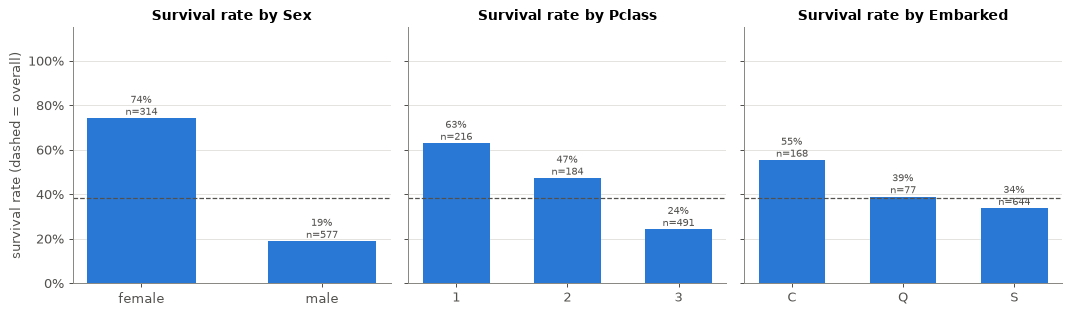

In [4]:
def survival_rate(df: pd.DataFrame, column: str) -> pd.DataFrame:
    """Survival rate and passenger count per category of `column`."""
    return df.groupby(column, observed=True)["Survived"].agg(rate="mean", passengers="size")


def plot_rates(ax: plt.Axes, rates: pd.DataFrame, title: str, overall: float) -> None:
    ax.bar(rates.index.astype(str), rates["rate"], color=SURVIVED_COLOR, width=0.6)
    ax.axhline(overall, color="#52514e", linestyle="--", linewidth=1)
    for x, (rate, n) in enumerate(zip(rates["rate"], rates["passengers"], strict=True)):
        ax.annotate(f"{rate:.0%}\nn={n}", (x, rate), ha="center", va="bottom", fontsize=8, color="#52514e")
    ax.set_title(title)
    ax.set_ylim(0, 1.15)
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))


overall_rate = train["Survived"].mean()
print(f"Overall survival rate: {overall_rate:.1%}")

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)
for ax, column in zip(axes, ["Sex", "Pclass", "Embarked"], strict=True):
    plot_rates(ax, survival_rate(train, column), f"Survival rate by {column}", overall_rate)
axes[0].set_ylabel("survival rate (dashed = overall)")
fig.tight_layout()
plt.show()

Sex and class dominate. The class effect is much stronger for women than for men, which is why tree models (or
interaction terms) tend to help here:

In [5]:
train.pivot_table(index="Sex", columns="Pclass", values="Survived", aggfunc="mean").style.format("{:.0%}")

Pclass,1,2,3
Sex,,,
female,97%,92%,50%
male,37%,16%,14%


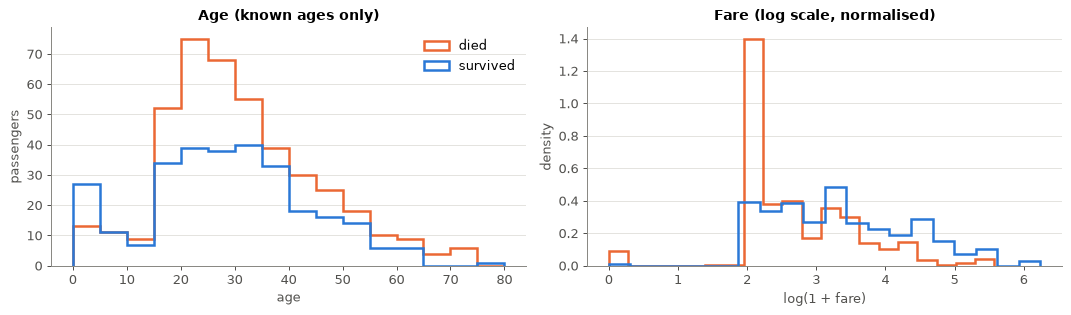

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
bins = np.arange(0, 85, 5)
for survived, color, label in [(0, DIED_COLOR, "died"), (1, SURVIVED_COLOR, "survived")]:
    subset = train[train["Survived"] == survived]
    axes[0].hist(subset["Age"].dropna(), bins=bins, histtype="step", linewidth=2, color=color, label=label)
    axes[1].hist(
        np.log1p(subset["Fare"]), bins=20, histtype="step", linewidth=2, color=color, label=label, density=True
    )
axes[0].set_title("Age (known ages only)")
axes[0].set_xlabel("age")
axes[0].set_ylabel("passengers")
axes[1].set_title("Fare (log scale, normalised)")
axes[1].set_xlabel("log(1 + fare)")
axes[1].set_ylabel("density")
axes[0].legend(frameon=False)
fig.tight_layout()
plt.show()

Young children (under 5) mostly survived ("women and children first"), while young adults (15-35) are dominated by
deaths - mostly third-class men. Passengers who paid more survived more often, largely a proxy for class and cabin
location.

## Feature engineering

The features below build on the ideas of the first version of this project (title scoring, family size, and grouping
passengers by surname/ticket), in a simpler and leak-free form:

| Feature | Idea |
|---|---|
| `Title` | Honorific parsed from `Name` (`Mr`, `Mrs`, `Miss`, `Master`, `Rare`). Encodes sex, age group and social rank at once; `Master` identifies boys, whose age is often missing. Rare titles (Dr, Rev, military ranks, nobility) are pooled because each has only a handful of passengers. |
| `FamilySize`, `FamilyType` | `SibSp + Parch + 1`, plus a solo / small (2-4) / large (5+) bucket - small families fared better than both solo travellers and large families. |
| `Deck` | First letter of `Cabin`, `U` when unknown. Having a recorded cabin at all is informative. |
| `TicketGroupSize` | Number of passengers (train + test) sharing the same ticket number - catches travel groups that are not relatives. Only uses the `Ticket` column, never the target. |
| `FarePerPerson` | `Fare` is the price of the whole ticket, so it is divided by the ticket group size. |
| `AgeMissing` | Flag set before imputation - whether age was recorded correlates with class and survival. |

These are deterministic, row-level transformations, so they can be computed before the train/validation split. The
steps that *learn* something from the data (imputation, scaling, encoding) come later, inside the pipeline.

In [7]:
RARE_TITLES = ["Dr", "Rev", "Col", "Major", "Capt", "Don", "Dona", "Sir", "Lady", "the Countess", "Jonkheer"]
TITLE_MAP = {"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"} | {title: "Rare" for title in RARE_TITLES}


def add_features(df: pd.DataFrame, ticket_counts: pd.Series) -> pd.DataFrame:
    """Return a copy of `df` with the engineered columns described above."""
    out = df.copy()
    title = out["Name"].str.extract(r",\s*([^.]+)\.", expand=False).str.strip()
    out["Title"] = title.replace(TITLE_MAP)
    out["FamilySize"] = out["SibSp"] + out["Parch"] + 1
    out["FamilyType"] = pd.cut(out["FamilySize"], bins=[0, 1, 4, np.inf], labels=["solo", "small", "large"]).astype(str)
    out["Deck"] = out["Cabin"].str[0].fillna("U")
    out["TicketGroupSize"] = out["Ticket"].map(ticket_counts).astype(int)
    out["FarePerPerson"] = out["Fare"] / out["TicketGroupSize"]
    out["AgeMissing"] = out["Age"].isna().astype(int)
    return out


ticket_counts = pd.concat([df["Ticket"] for df in frames.values()]).value_counts()
train_fe = add_features(train, ticket_counts)
test_fe = add_features(test, ticket_counts) if test is not None else None

train_fe[["Name", "Title", "FamilySize", "FamilyType", "Deck", "TicketGroupSize", "FarePerPerson", "AgeMissing"]].head()

,Name,Title,FamilySize,FamilyType,Deck,TicketGroupSize,FarePerPerson,AgeMissing
PassengerId,,,,,,,,
1,"Braund, Mr. Owen Harris",Mr,2,small,U,1,7.250,0
2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,2,small,C,2,35.642,0
3,"Heikkinen, Miss. Laina",Miss,1,solo,U,1,7.925,0
4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,2,small,C,2,26.550,0
5,"Allen, Mr. William Henry",Mr,1,solo,U,1,8.050,0


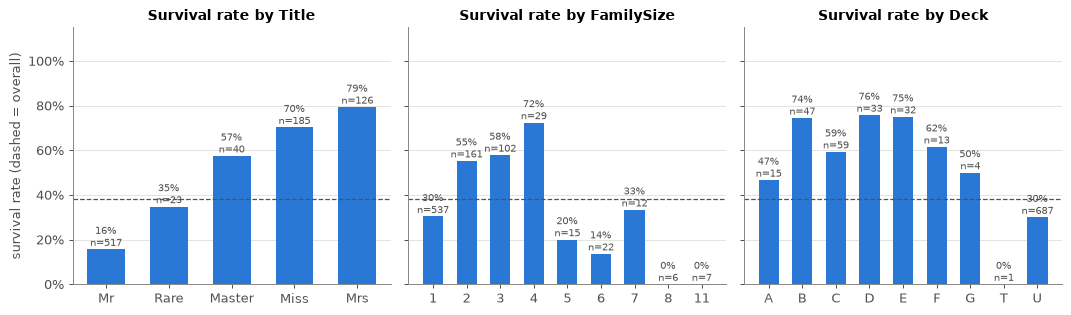

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)
panels = [
    (survival_rate(train_fe, "Title").sort_values("rate"), "Survival rate by Title"),
    (survival_rate(train_fe, "FamilySize"), "Survival rate by FamilySize"),
    (survival_rate(train_fe, "Deck"), "Survival rate by Deck"),
]
for ax, (rates, title) in zip(axes, panels, strict=True):
    plot_rates(ax, rates, title, overall_rate)
axes[0].set_ylabel("survival rate (dashed = overall)")
fig.tight_layout()
plt.show()

- `Master` (boys) survived far more often than `Mr`, which `Sex` alone cannot express.
- Family size has the expected inverted-U shape: 2-4 people is the sweet spot, very large families almost all died.
- Passengers with a known deck survived much more often than those without (`U`); the deck letter itself adds less.

## Preprocessing pipeline

Two custom pieces and one `ColumnTransformer`:

- `GroupMedianImputer` fills missing `Age` with the median age of the passenger's `Title`, learned in `fit` - the
  same idea as the original notebook's age-by-title imputation, but fitted only on the training fold.
- Numeric columns: median imputation + standard scaling (`FarePerPerson` is log-transformed first because it is very
  skewed). Scaling does not matter for tree models but lets linear models and SVMs share the same pipeline.
- Categorical columns: most-frequent imputation (covers the two missing `Embarked` values) + one-hot encoding.
  Categories with fewer than 10 training passengers are pooled by the encoder, and unseen categories at prediction
  time are ignored instead of raising.

In [9]:
class GroupMedianImputer(BaseEstimator, TransformerMixin):
    """Fill NaNs in `column` with the median of that column within each `group_by` category."""

    def __init__(self, column: str = "Age", group_by: str = "Title"):
        self.column = column
        self.group_by = group_by

    def fit(self, X: pd.DataFrame, y=None) -> "GroupMedianImputer":
        self.group_medians_ = X.groupby(self.group_by)[self.column].median()
        self.global_median_ = X[self.column].median()
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        X = X.copy()
        fallback = X[self.group_by].map(self.group_medians_).fillna(self.global_median_)
        X[self.column] = X[self.column].fillna(fallback)
        return X


NUMERIC = ["Pclass", "Age", "SibSp", "Parch", "FamilySize", "TicketGroupSize", "AgeMissing"]
SKEWED = ["FarePerPerson"]
CATEGORICAL = ["Sex", "Embarked", "Title", "FamilyType", "Deck"]


def build_preprocessor() -> ColumnTransformer:
    numeric = Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())])
    skewed = Pipeline(
        [
            ("impute", SimpleImputer(strategy="median")),
            ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
            ("scale", StandardScaler()),
        ]
    )
    categorical = Pipeline(
        [
            ("impute", SimpleImputer(strategy="most_frequent")),
            (
                "onehot",
                OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=10, sparse_output=False),
            ),
        ]
    )
    return ColumnTransformer(
        [("num", numeric, NUMERIC), ("skewed", skewed, SKEWED), ("cat", categorical, CATEGORICAL)],
        verbose_feature_names_out=False,
    )


def build_pipeline(model: BaseEstimator) -> Pipeline:
    return Pipeline(
        [("age_imputer", GroupMedianImputer("Age", "Title")), ("preprocess", build_preprocessor()), ("model", model)]
    )


X = train_fe.drop(columns="Survived")
y = train_fe["Survived"]

preview = build_pipeline(LogisticRegression()).fit(X, y)
print(f"{len(preview['preprocess'].get_feature_names_out())} model features:")
print(", ".join(preview["preprocess"].get_feature_names_out()))

29 model features:
Pclass, Age, SibSp, Parch, FamilySize, TicketGroupSize, AgeMissing, FarePerPerson, Sex_female, Sex_male, Embarked_C, Embarked_Q, Embarked_S, Title_Master, Title_Miss, Title_Mr, Title_Mrs, Title_Rare, FamilyType_large, FamilyType_small, FamilyType_solo, Deck_A, Deck_B, Deck_C, Deck_D, Deck_E, Deck_F, Deck_U, Deck_infrequent_sklearn


## Model comparison

5-fold stratified CV repeated 3 times (15 fits per model, same splits for every model), reporting mean and standard
deviation of validation accuracy, plus the mean training accuracy to spot overfitting. The references are:

- **Majority class** - always predict "died".
- **Rule: women survive** - predict survival for every female passenger and nothing else (no fitting).
- **Decision tree, original features** - an approximation of this project's first attempt: an unpruned decision tree on
  sex, title and family size only.

In [10]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)

original_features = ColumnTransformer(
    [
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["Sex", "Title"]),
        ("num", "passthrough", ["FamilySize"]),
    ]
)
models = {
    "Majority class": build_pipeline(DummyClassifier(strategy="most_frequent")),
    "Decision tree, original features": Pipeline(
        [("features", original_features), ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))]
    ),
    "Logistic regression": build_pipeline(LogisticRegression(max_iter=1000)),
    "SVM (RBF)": build_pipeline(SVC()),
    "Random forest": build_pipeline(
        RandomForestClassifier(n_estimators=300, min_samples_leaf=2, random_state=RANDOM_STATE)
    ),
    "Gradient boosting": build_pipeline(GradientBoostingClassifier(random_state=RANDOM_STATE)),
}

rows = []
for name, pipeline in models.items():
    scores = cross_validate(pipeline, X, y, cv=cv, scoring="accuracy", return_train_score=True, n_jobs=N_JOBS)
    rows.append(
        {
            "model": name,
            "cv_accuracy": scores["test_score"].mean(),
            "cv_std": scores["test_score"].std(),
            "train_accuracy": scores["train_score"].mean(),
        }
    )

women_survive = X["Sex"].eq("female").astype(int)
rule_scores = np.array([(women_survive.iloc[idx] == y.iloc[idx]).mean() for _, idx in cv.split(X, y)])
rows.append(
    {
        "model": "Rule: women survive",
        "cv_accuracy": rule_scores.mean(),
        "cv_std": rule_scores.std(),
        "train_accuracy": np.nan,
    }
)

results = pd.DataFrame(rows).set_index("model").sort_values("cv_accuracy", ascending=False)
results

,cv_accuracy,cv_std,train_accuracy
model,,,
Gradient boosting,0.838,0.017,0.913
Random forest,0.827,0.015,0.909
SVM (RBF),0.827,0.020,0.845
Logistic regression,0.827,0.022,0.838
"Decision tree, original features",0.822,0.027,0.829
Rule: women survive,0.787,0.021,NaN
Majority class,0.616,0.002,0.616


- Every model clears both references comfortably; the one-line "women survive" rule already reaches ~79%.
- The four model families on the engineered features land within about one standard deviation of each other
  (0.827-0.838). Gradient boosting has the best mean, so it is the one tuned below - but the gap is small relative to
  the fold-to-fold noise on 891 passengers.
- The three-feature decision tree from the original attempt is only ~1.5 points behind: most of the signal lives in
  sex, title and family size. The extra features buy a small, consistent gain rather than a step change.
- The tree ensembles fit their training folds much better than they validate (~0.91 vs 0.83-0.84), while logistic
  regression and the SVM show almost no gap.

## Hyperparameter tuning

A small grid for gradient boosting, searched with 5-fold stratified CV. The best grid-search score is optimistic (it
is the maximum over many noisy estimates), so the tuned configuration is also evaluated with **nested CV**: the
whole grid search is repeated inside each outer fold and scored on data it never saw.

In [11]:
grid = GridSearchCV(
    build_pipeline(GradientBoostingClassifier(random_state=RANDOM_STATE)),
    param_grid={
        "model__n_estimators": [100, 300],
        "model__learning_rate": [0.03, 0.1],
        "model__max_depth": [2, 3, 4],
        "model__subsample": [0.8, 1.0],
    },
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring="accuracy",
    n_jobs=N_JOBS,
)

In [12]:
grid.fit(X, y)
print(f"Best params: {grid.best_params_}")
print(f"Best inner-CV accuracy (optimistic): {grid.best_score_:.3f}")

# Nested CV: the full grid search runs inside each outer training fold, so every prediction below is made by a
# model whose hyperparameters were chosen without seeing that passenger.
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE + 1)
nested_pred = cross_val_predict(grid, X, y, cv=outer_cv, n_jobs=N_JOBS)
nested_scores = np.array([(nested_pred[idx] == y.iloc[idx]).mean() for _, idx in outer_cv.split(X, y)])
print(f"Nested-CV accuracy: {nested_scores.mean():.3f} +/- {nested_scores.std():.3f}")

Best params: {'model__learning_rate': 0.03, 'model__max_depth': 4, 'model__n_estimators': 300, 'model__subsample': 0.8}
Best inner-CV accuracy (optimistic): 0.850


Nested-CV accuracy: 0.828 +/- 0.016


The grid picks a slower, deeper configuration (learning rate 0.03, depth 4, 300 trees, 80% row subsampling) with an
inner-CV accuracy of 0.850. Nested CV tells a more sober story: **0.828 +/- 0.016**, no better than the untuned
gradient boosting in the comparison above (0.838 +/- 0.017, on different splits). With 891 rows the best grid score is
largely selection noise - exactly what nested CV is there to expose. The tuned model is kept as the final model, with
the nested-CV figure as its performance estimate.

## Final model

`GridSearchCV` has already refitted the best configuration on the full training set; that is the model used for the
submission. The nested-CV out-of-fold predictions show what kind of errors the tuned procedure makes:

              precision    recall  f1-score   support

        died      0.849     0.878     0.863       549
    survived      0.793     0.749     0.770       342

    accuracy                          0.828       891
   macro avg      0.821     0.813     0.816       891
weighted avg      0.827     0.828     0.827       891



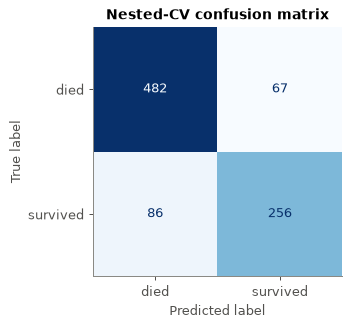

In [13]:
final_model = grid.best_estimator_

print(classification_report(y, nested_pred, target_names=["died", "survived"], digits=3))

fig, ax = plt.subplots(figsize=(4, 3.6))
ConfusionMatrixDisplay.from_predictions(
    y, nested_pred, display_labels=["died", "survived"], cmap="Blues", colorbar=False, ax=ax
)
ax.grid(False)
ax.set_title("Nested-CV confusion matrix")
plt.show()

Where do the errors come from? Error rate of the nested-CV predictions by sex and class:

In [14]:
(
    X[["Sex", "Pclass"]]
    .assign(survived=y, error=(nested_pred != y).astype(int))
    .groupby(["Sex", "Pclass"])
    .agg(passengers=("survived", "size"), survival_rate=("survived", "mean"), error_rate=("error", "mean"))
)

passengers  survival_rate  error_rate
Sex    Pclass                                       
female 1               94          0.968       0.043
       2               76          0.921       0.079
       3              144          0.500       0.354
male   1              122          0.369       0.361
       2              108          0.157       0.083
       3              347          0.135       0.112

The errors concentrate in the two groups whose outcome is closest to a coin flip: third-class women (50% survival,
35% error rate) and first-class men (37% survival, 36% error rate). For every other sex/class combination the model is
right 89-96% of the time. Those two groups are where extra information - for example whether other members of the
same family or ticket survived - would help most.

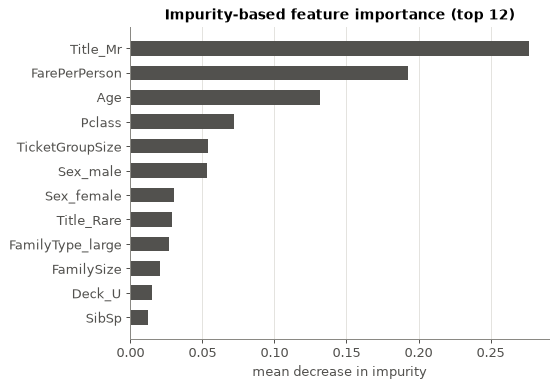

In [15]:
feature_names = final_model["preprocess"].get_feature_names_out()
importances = pd.Series(final_model["model"].feature_importances_, index=feature_names).sort_values()

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.barh(importances.index[-12:], importances.values[-12:], color="#52514e", height=0.6)
ax.grid(axis="x")
ax.grid(axis="y", visible=False)
ax.set_title("Impurity-based feature importance (top 12)")
ax.set_xlabel("mean decrease in impurity")
plt.show()

`Title_Mr` is by far the most used feature: it separates adult men (16% survival) from everyone else, combining sex
and age in one column. Fare per person, age and class follow. Impurity-based importances are biased towards
continuous features with many split points (fare, age), so this ranking is indicative only; permutation importance
on held-out folds would be the more careful check.

## Submission

Predict on `data/test.csv` and write the Kaggle submission file. The step is skipped when the test file is not
available.

In [16]:
if test_fe is None:
    print(f"{test_path} not found - skipping the submission file.")
else:
    submission = pd.DataFrame({"PassengerId": test_fe.index, "Survived": final_model.predict(test_fe)})
    SUBMISSION_PATH.parent.mkdir(parents=True, exist_ok=True)
    submission.to_csv(SUBMISSION_PATH, index=False)
    print(f"Wrote {len(submission)} predictions to {SUBMISSION_PATH}")
    print(f"Predicted survival rate on test: {submission['Survived'].mean():.1%}")

Wrote 418 predictions to submissions/submission.csv
Predicted survival rate on test: 39.5%


## Results and next steps

| Model | CV accuracy (5x3 repeated stratified) |
|---|---|
| Majority class | 0.616 +/- 0.002 |
| Rule: women survive | 0.787 +/- 0.021 |
| Decision tree, original features | 0.822 +/- 0.027 |
| Logistic regression | 0.827 +/- 0.022 |
| SVM (RBF) | 0.827 +/- 0.020 |
| Random forest | 0.827 +/- 0.015 |
| **Gradient boosting** | **0.838 +/- 0.017** |
| Gradient boosting, tuned (nested 5-fold CV) | 0.828 +/- 0.016 |

- Engineered features + a leak-free pipeline reach ~0.83-0.84 cross-validated accuracy, about 5 points above the
  "women survive" rule and 1-2 points above the original three-feature tree.
- Hyperparameter tuning did not produce a measurable gain once evaluated with nested CV.
- The submission file has not been scored on the Kaggle leaderboard here, so no leaderboard number is claimed.

Ideas for a next iteration:

- **Group survival features** - whether other members of a passenger's family or ticket group survived. This is the
  idea the original surname/ticket analysis was heading towards and targets the third-class women / first-class men
  errors above; it has to be computed inside each CV fold to avoid target leakage.
- **Permutation importance on held-out folds** and pruning features that do not help.
- **Soft-voting ensemble** of the linear model, SVM and gradient boosting, whose errors are only partly correlated.